In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
ZIP_PATH = "/content/drive/MyDrive/LG Aimers 9기/release data/open.zip"

In [6]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

GROUP2_COLS = [
    "balls_before",
    "strikes_before",
    "outs_before",
    "run_top_before",
    "run_bot_before",
    "run_total_before",
    "score_diff_home",
    "score_diff_pitcher_team",
]

AUX_COLS = [
    "season",
    "inning",
    "top_bottom",
]

TARGET = "control_success"

USE_COLS = GROUP2_COLS + AUX_COLS + [TARGET]

print("분석 컬럼 수:", len(GROUP2_COLS))
print(GROUP2_COLS)

분석 컬럼 수: 8
['balls_before', 'strikes_before', 'outs_before', 'run_top_before', 'run_bot_before', 'run_total_before', 'score_diff_home', 'score_diff_pitcher_team']


In [7]:
with zipfile.ZipFile(ZIP_PATH) as z:
    print(z.namelist())

['baseline_submit.zip', 'data/', 'data/sample_submission.csv', 'data/test.csv', 'data/trackman_history.csv', 'data/train.csv', 'data_description.md']


In [8]:
with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open("data/train.csv") as f:
        df = pd.read_csv(f, usecols=USE_COLS)

print("shape:", df.shape)
df.head()

shape: (1475092, 12)


,season,inning,top_bottom,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,score_diff_home,score_diff_pitcher_team,control_success
0,2019,1,T,0,0,0,0,0,0,0,0,0
1,2019,1,T,0,0,0,0,0,0,0,0,0
2,2019,1,T,1,0,0,0,0,0,0,0,0
3,2019,1,T,0,0,2,0,0,0,0,0,1
4,2019,1,T,0,1,2,0,0,0,0,0,1


# **3. 전체 구조 확인**

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475092 entries, 0 to 1475091
Data columns (total 12 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   season                   1475092 non-null  int64 
 1   inning                   1475092 non-null  int64 
 2   top_bottom               1475092 non-null  object
 3   balls_before             1475092 non-null  int64 
 4   strikes_before           1475092 non-null  int64 
 5   outs_before              1475092 non-null  int64 
 6   run_top_before           1475092 non-null  int64 
 7   run_bot_before           1475092 non-null  int64 
 8   run_total_before         1475092 non-null  int64 
 9   score_diff_home          1475092 non-null  int64 
 10  score_diff_pitcher_team  1475092 non-null  int64 
 11  control_success          1475092 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 135.0+ MB
None


In [10]:
print("\n전체 행 수:", len(df))
print("Target 평균:", df[TARGET].mean())
print("\n시즌별 행 수:")
print(df["season"].value_counts().sort_index())


전체 행 수: 1475092
Target 평균: 0.5237659752747625

시즌별 행 수:
season
2019    237413
2020    244087
2021    247088
2022    247472
2023    245525
2024    253507
Name: count, dtype: int64


# **4. Data Quality Table 만들기**


In [11]:
quality_rows = []

for col in GROUP2_COLS:
    s = df[col]

    quality_rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "missing_n": s.isna().sum(),
        "missing_pct": s.isna().mean() * 100,
        "nunique": s.nunique(dropna=False),
        "min": s.min(),
        "max": s.max(),
        "mean": s.mean(),
        "std": s.std(),
        "median": s.median(),
    })

quality_df = pd.DataFrame(quality_rows)

quality_df

,column,dtype,missing_n,missing_pct,nunique,min,max,mean,std,median
0,balls_before,int64,0,0.0,4,0,3,0.898468,0.969742,1.0
1,strikes_before,int64,0,0.0,3,0,2,0.871871,0.824605,1.0
2,outs_before,int64,0,0.0,3,0,2,0.981432,0.816727,1.0
3,run_top_before,int64,0,0.0,30,0,30,2.557856,2.914232,2.0
4,run_bot_before,int64,0,0.0,25,0,26,2.357027,2.766365,1.0
5,run_total_before,int64,0,0.0,38,0,37,4.914883,4.500625,4.0
6,score_diff_home,int64,0,0.0,47,-27,20,-0.200829,3.469210,0.0
7,score_diff_pitcher_team,int64,0,0.0,52,-27,27,0.060107,3.474498,0.0


# **5. 야구 규칙상 값 범위 확인**

In [12]:
print("balls_before:", sorted(df["balls_before"].unique()))
print("strikes_before:", sorted(df["strikes_before"].unique()))
print("outs_before:", sorted(df["outs_before"].unique()))

balls_before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
strikes_before: [np.int64(0), np.int64(1), np.int64(2)]
outs_before: [np.int64(0), np.int64(1), np.int64(2)]


In [13]:
assert df["balls_before"].between(0, 3).all()
assert df["strikes_before"].between(0, 2).all()
assert df["outs_before"].between(0, 2).all()

print("카운트 범위 검사 통과")

카운트 범위 검사 통과


# **6. 중요한 중복 관계 검증**

## run_total 검증

In [14]:
check_total = (
    df["run_total_before"]
    ==
    df["run_top_before"] + df["run_bot_before"]
)

print("run_total 일치율:", check_total.mean())
print("불일치 행 수:", (~check_total).sum())

run_total 일치율: 1.0
불일치 행 수: 0


## score_diff_home 검증

In [15]:
check_home_diff = (
    df["score_diff_home"]
    ==
    df["run_bot_before"] - df["run_top_before"]
)

print("score_diff_home 일치율:", check_home_diff.mean())
print("불일치 행 수:", (~check_home_diff).sum())

score_diff_home 일치율: 1.0
불일치 행 수: 0


## score_diff_pitcher_team 검증

초(T)에는 원정팀이 공격하므로 투수팀은 홈팀

In [16]:
expected_pitcher_diff = np.where(
    df["top_bottom"].eq("T"),
    df["score_diff_home"],
    -df["score_diff_home"]
)

check_pitcher_diff = (
    expected_pitcher_diff
    ==
    df["score_diff_pitcher_team"]
)

print("score_diff_pitcher_team 일치율:", check_pitcher_diff.mean())
print("불일치 행 수:", (~check_pitcher_diff).sum())

score_diff_pitcher_team 일치율: 1.0
불일치 행 수: 0


# **7. 카운트 변수 분포**

In [17]:
for col in ["balls_before", "strikes_before", "outs_before"]:
    print(f"\n===== {col} =====")
    print(
        df[col]
        .value_counts()
        .sort_index()
        .to_frame("count")
        .assign(ratio=lambda x: x["count"] / len(df))
    )


===== balls_before =====
               count     ratio
balls_before                  
0             652052  0.442042
1             444780  0.301527
2             254237  0.172353
3             124023  0.084078

===== strikes_before =====
                 count     ratio
strikes_before                  
0               608121  0.412260
1               447852  0.303610
2               419119  0.284131

===== outs_before =====
              count     ratio
outs_before                  
0            505924  0.342978
1            490634  0.332612
2            478534  0.324410


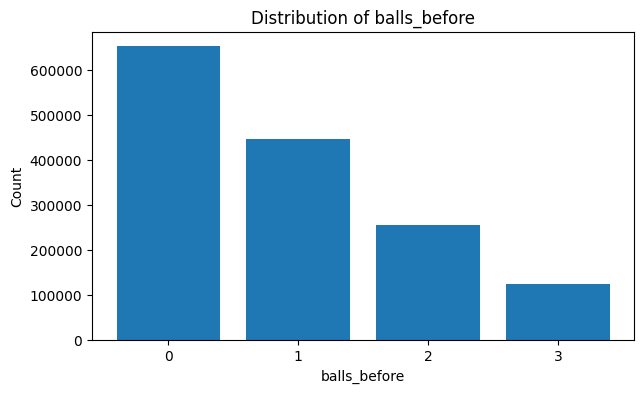

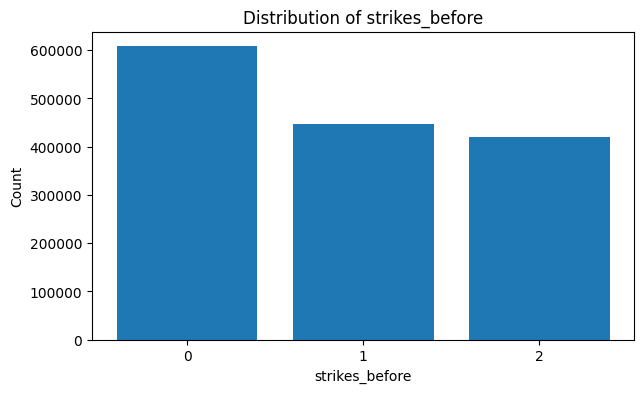

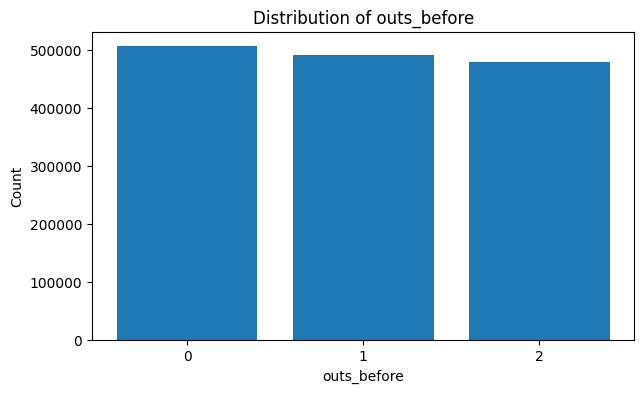

In [18]:
for col in ["balls_before", "strikes_before", "outs_before"]:
    counts = df[col].value_counts().sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# **8. Target 기준 전체 성공률**


> 앞으로 모든 상황 성공률은 이 값과 비교하면 됨



In [19]:
overall_rate = df[TARGET].mean()

print(f"전체 control_success 비율: {overall_rate:.6f}")
print(f"전체 control_success 비율: {overall_rate*100:.2f}%")

전체 control_success 비율: 0.523766
전체 control_success 비율: 52.38%


# **9. 변수별 성공률 자동 계산 함수**

> 반복작업을 줄이자



In [20]:
def target_rate_table(data, col, target="control_success"):
    result = (
        data
        .groupby(col, dropna=False)[target]
        .agg(["count", "mean"])
        .reset_index()
    )

    overall = data[target].mean()

    result = result.rename(columns={
        "mean": "success_rate"
    })

    result["success_rate_pct"] = result["success_rate"] * 100

    result["diff_vs_overall_pp"] = (
        result["success_rate"] - overall
    ) * 100

    return result

In [21]:
balls_result = target_rate_table(df, "balls_before")
balls_result

,balls_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,652052,0.527568,52.756835,0.380238
1,1,444780,0.525941,52.594091,0.217494
2,2,254237,0.520782,52.078179,-0.298419
3,3,124023,0.502092,50.209235,-2.167362


그리고 나머지

In [22]:
for col in [
    "balls_before",
    "strikes_before",
    "outs_before",
]:
    print(f"\n===== {col} vs control_success =====")
    display(target_rate_table(df, col))


===== balls_before vs control_success =====


,balls_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,652052,0.527568,52.756835,0.380238
1,1,444780,0.525941,52.594091,0.217494
2,2,254237,0.520782,52.078179,-0.298419
3,3,124023,0.502092,50.209235,-2.167362



===== strikes_before vs control_success =====


,strikes_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,608121,0.524874,52.487416,0.110819
1,1,447852,0.527643,52.764306,0.387709
2,2,419119,0.518015,51.801517,-0.575081



===== outs_before vs control_success =====


,outs_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,505924,0.521398,52.139847,-0.236750
1,1,490634,0.523894,52.389357,0.012760
2,2,478534,0.526138,52.613816,0.237219


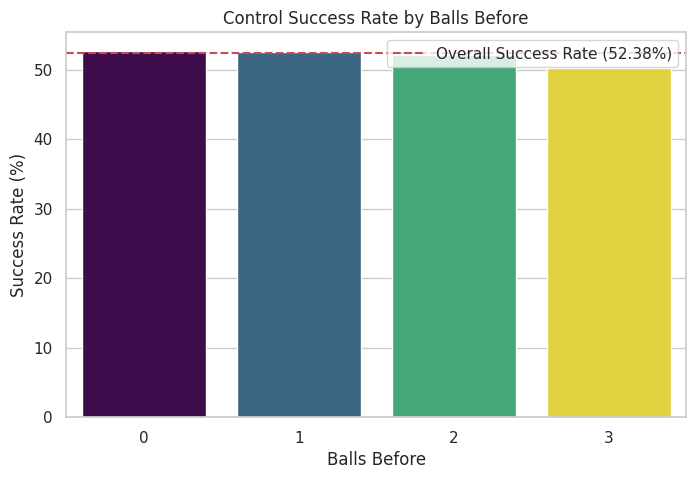

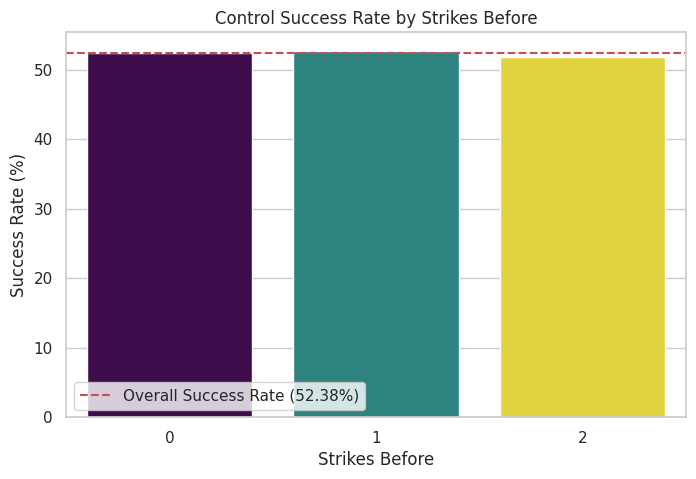

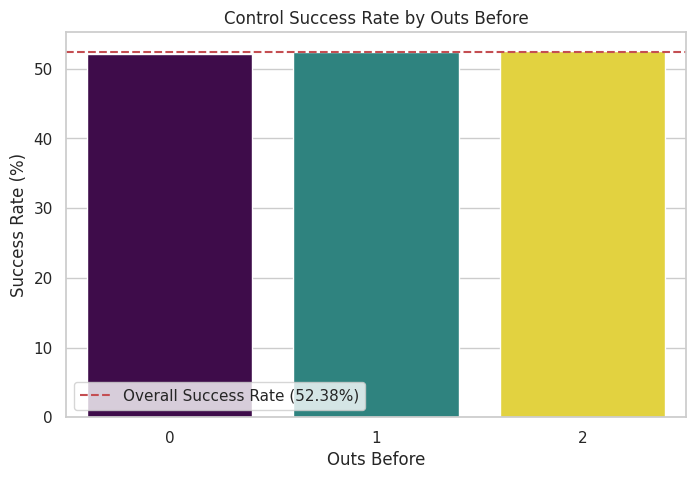

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

for col in [
    "balls_before",
    "strikes_before",
    "outs_before",
]:
    df_result = target_rate_table(df, col)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=col, y="success_rate_pct", data=df_result, palette="viridis", hue=col, legend=False)
    plt.axhline(y=overall_rate * 100, color='r', linestyle='--', label=f'Overall Success Rate ({overall_rate*100:.2f}%)')
    plt.title(f'Control Success Rate by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Success Rate (%)')
    plt.legend()
    plt.show()

# **10. 중요한 Balls × Strikes 분석**

단일 변수보다 이게 중요.

In [24]:
count_table = (
    df
    .groupby(["balls_before", "strikes_before"])[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

count_table["success_rate_pct"] = count_table["mean"] * 100

count_table["diff_vs_overall_pp"] = (
    count_table["mean"] - overall_rate
) * 100

count_table = count_table.sort_values(
    ["balls_before", "strikes_before"]
)

count_table

,balls_before,strikes_before,count,mean,success_rate_pct,diff_vs_overall_pp
0,0,0,380996,0.526567,52.656721,0.280123
1,0,1,181775,0.534105,53.410535,1.033937
2,0,2,89281,0.518531,51.853138,-0.523460
3,1,0,154878,0.524852,52.485182,0.108584
4,1,1,150304,0.528456,52.845566,0.468969
5,1,2,139598,0.524442,52.444161,0.067564
6,2,0,54187,0.518888,51.888829,-0.487768
7,2,1,80348,0.521755,52.175536,-0.201061
8,2,2,119702,0.520985,52.098545,-0.278053
9,3,0,18060,0.507309,50.730897,-1.645701


In [25]:
count_table["count_state"] = (
    count_table["balls_before"].astype(str)
    + "-"
    + count_table["strikes_before"].astype(str)
)

display(
    count_table[
        [
            "count_state",
            "count",
            "success_rate_pct",
            "diff_vs_overall_pp"
        ]
    ]
)

,count_state,count,success_rate_pct,diff_vs_overall_pp
0,0-0,380996,52.656721,0.280123
1,0-1,181775,53.410535,1.033937
2,0-2,89281,51.853138,-0.523460
3,1-0,154878,52.485182,0.108584
4,1-1,150304,52.845566,0.468969
5,1-2,139598,52.444161,0.067564
6,2-0,54187,51.888829,-0.487768
7,2-1,80348,52.175536,-0.201061
8,2-2,119702,52.098545,-0.278053
9,3-0,18060,50.730897,-1.645701


# **11. Count 성공률 Heatmap**

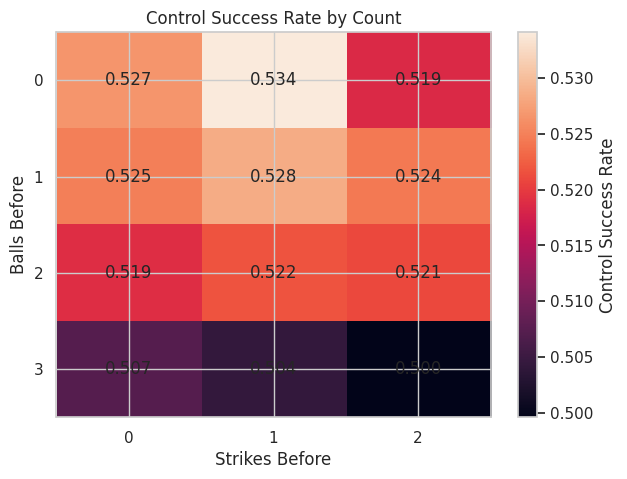

In [26]:
count_pivot = df.pivot_table(
    index="balls_before",
    columns="strikes_before",
    values=TARGET,
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))

img = plt.imshow(
    count_pivot.values,
    aspect="auto"
)

plt.colorbar(img, label="Control Success Rate")

plt.xticks(
    range(len(count_pivot.columns)),
    count_pivot.columns
)

plt.yticks(
    range(len(count_pivot.index)),
    count_pivot.index
)

plt.xlabel("Strikes Before")
plt.ylabel("Balls Before")
plt.title("Control Success Rate by Count")

for i in range(count_pivot.shape[0]):
    for j in range(count_pivot.shape[1]):
        val = count_pivot.iloc[i, j]

        plt.text(
            j,
            i,
            f"{val:.3f}",
            ha="center",
            va="center"
        )

plt.show()

# **12. Count별 표본 수도 같이 확인**

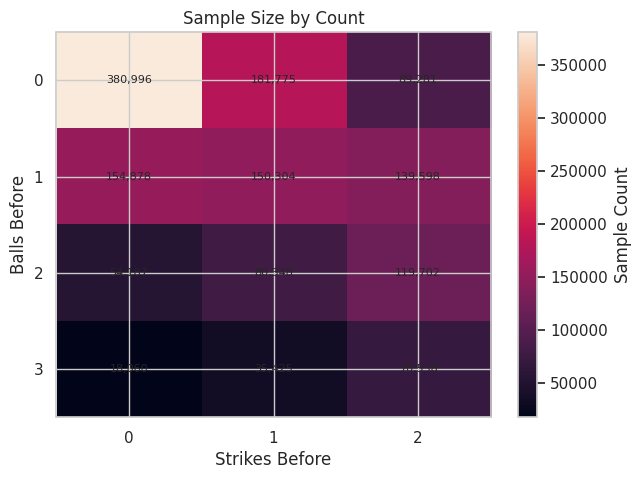

In [27]:
count_n_pivot = df.pivot_table(
    index="balls_before",
    columns="strikes_before",
    values=TARGET,
    aggfunc="count"
)

plt.figure(figsize=(7, 5))

img = plt.imshow(
    count_n_pivot.values,
    aspect="auto"
)

plt.colorbar(img, label="Sample Count")

plt.xticks(
    range(len(count_n_pivot.columns)),
    count_n_pivot.columns
)

plt.yticks(
    range(len(count_n_pivot.index)),
    count_n_pivot.index
)

plt.xlabel("Strikes Before")
plt.ylabel("Balls Before")
plt.title("Sample Size by Count")

for i in range(count_n_pivot.shape[0]):
    for j in range(count_n_pivot.shape[1]):
        val = count_n_pivot.iloc[i, j]

        plt.text(
            j,
            i,
            f"{val:,}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.show()

# **13. 3볼과 풀카운트를 따로 보기**

In [28]:
df["is_three_ball"] = (
    df["balls_before"] == 3
).astype(int)

df["is_full_count"] = (
    (df["balls_before"] == 3)
    &
    (df["strikes_before"] == 2)
).astype(int)

In [29]:
display(
    target_rate_table(df, "is_three_ball")
)

display(
    target_rate_table(df, "is_full_count")
)

,is_three_ball,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,1351069,0.525756,52.575553,0.198956
1,1,124023,0.502092,50.209235,-2.167362


,is_full_count,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,1404554,0.524979,52.497946,0.121348
1,1,70538,0.499603,49.960305,-2.416292


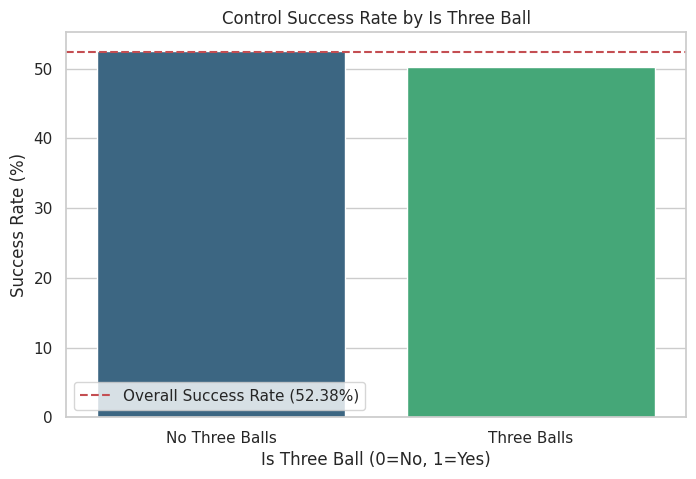

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot for is_three_ball
df_three_ball_result = target_rate_table(df, "is_three_ball")
plt.figure(figsize=(8, 5))
sns.barplot(x="is_three_ball", y="success_rate_pct", data=df_three_ball_result, palette="viridis", hue="is_three_ball", legend=False)
plt.axhline(y=overall_rate * 100, color='r', linestyle='--', label=f'Overall Success Rate ({overall_rate*100:.2f}%)')
plt.title('Control Success Rate by Is Three Ball')
plt.xlabel('Is Three Ball (0=No, 1=Yes)')
plt.ylabel('Success Rate (%)')
plt.xticks([0, 1], ['No Three Balls', 'Three Balls'])
plt.legend()
plt.show()

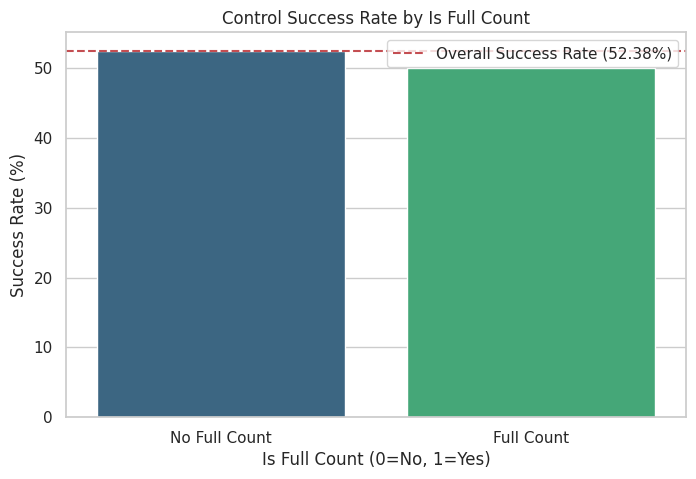

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot for is_full_count
df_full_count_result = target_rate_table(df, "is_full_count")
plt.figure(figsize=(8, 5))
sns.barplot(x="is_full_count", y="success_rate_pct", data=df_full_count_result, palette="viridis", hue="is_full_count", legend=False)
plt.axhline(y=overall_rate * 100, color='r', linestyle='--', label=f'Overall Success Rate ({overall_rate*100:.2f}%)')
plt.title('Control Success Rate by Is Full Count')
plt.xlabel('Is Full Count (0=No, 1=Yes)')
plt.ylabel('Success Rate (%)')
plt.xticks([0, 1], ['No Full Count', 'Full Count'])
plt.legend()
plt.show()

# **14. Outs별 성공률**

In [32]:
outs_table = target_rate_table(
    df,
    "outs_before"
)

outs_table

,outs_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,505924,0.521398,52.139847,-0.236750
1,1,490634,0.523894,52.389357,0.012760
2,2,478534,0.526138,52.613816,0.237219


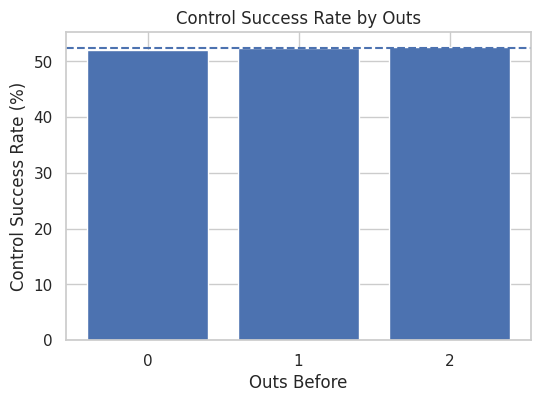

In [33]:
plt.figure(figsize=(6, 4))

plt.bar(
    outs_table["outs_before"].astype(str),
    outs_table["success_rate_pct"]
)

plt.axhline(
    overall_rate * 100,
    linestyle="--"
)

plt.xlabel("Outs Before")
plt.ylabel("Control Success Rate (%)")
plt.title("Control Success Rate by Outs")

plt.show()

# **15. Count × Outs까지 확장**

In [34]:
count_outs = (
    df
    .groupby(
        [
            "balls_before",
            "strikes_before",
            "outs_before"
        ]
    )[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

count_outs["success_rate_pct"] = (
    count_outs["mean"] * 100
)

count_outs.sort_values(
    "success_rate_pct"
).head(20)

,balls_before,strikes_before,outs_before,count,mean,success_rate_pct
30,3,1,0,11711,0.489796,48.979592
33,3,2,0,23441,0.491831,49.183055
27,3,0,0,5991,0.491905,49.190452
34,3,2,1,23027,0.498024,49.802406
29,3,0,2,6097,0.503034,50.303428
31,3,1,1,11651,0.504764,50.476354
35,3,2,2,24070,0.508683,50.868301
18,2,0,0,17958,0.511360,51.135984
21,2,1,0,27111,0.515621,51.562097
8,0,2,2,28342,0.515631,51.563051


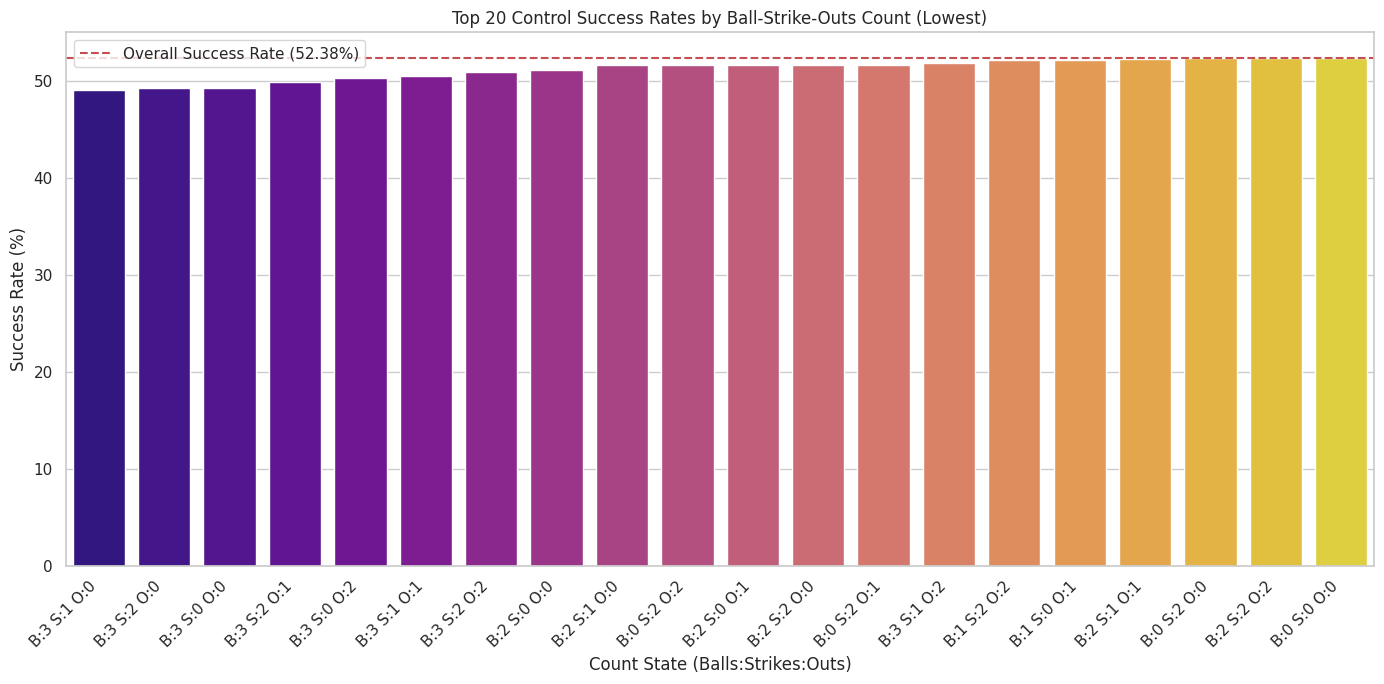

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Get the top 20 lowest success rate combinations from the already processed count_outs DataFrame
top_20_lowest_success = count_outs.sort_values(
    "success_rate_pct",
    ascending=True
).head(20)

# Create a combined count state for plotting for better readability on the x-axis
top_20_lowest_success["count_state"] = (
    'B:' + top_20_lowest_success["balls_before"].astype(str) +
    ' S:' + top_20_lowest_success["strikes_before"].astype(str) +
    ' O:' + top_20_lowest_success["outs_before"].astype(str)
)

plt.figure(figsize=(14, 7))
# Use hue to ensure each bar has a distinct color, and set legend=False as hue is self-explanatory from x-axis
sns.barplot(x="count_state", y="success_rate_pct", data=top_20_lowest_success, palette="plasma", hue="count_state", legend=False)
plt.axhline(y=overall_rate * 100, color='r', linestyle='--', label=f'Overall Success Rate ({overall_rate*100:.2f}%)')
plt.title('Top 20 Control Success Rates by Ball-Strike-Outs Count (Lowest)')
plt.xlabel('Count State (Balls:Strikes:Outs)')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [36]:
count_outs.sort_values(
    "success_rate_pct",
    ascending=False
).head(20)

,balls_before,strikes_before,outs_before,count,mean,success_rate_pct
3,0,1,0,63767,0.536422,53.642166
4,0,1,1,60539,0.535242,53.524174
14,1,1,2,48893,0.532448,53.244841
5,0,1,2,57469,0.530338,53.033810
2,0,0,2,121906,0.530146,53.014618
20,2,0,2,18106,0.529548,52.954822
11,1,0,2,50874,0.528954,52.895389
16,1,2,1,46716,0.528556,52.855553
23,2,1,2,26660,0.527794,52.779445
13,1,1,1,49891,0.527149,52.714919


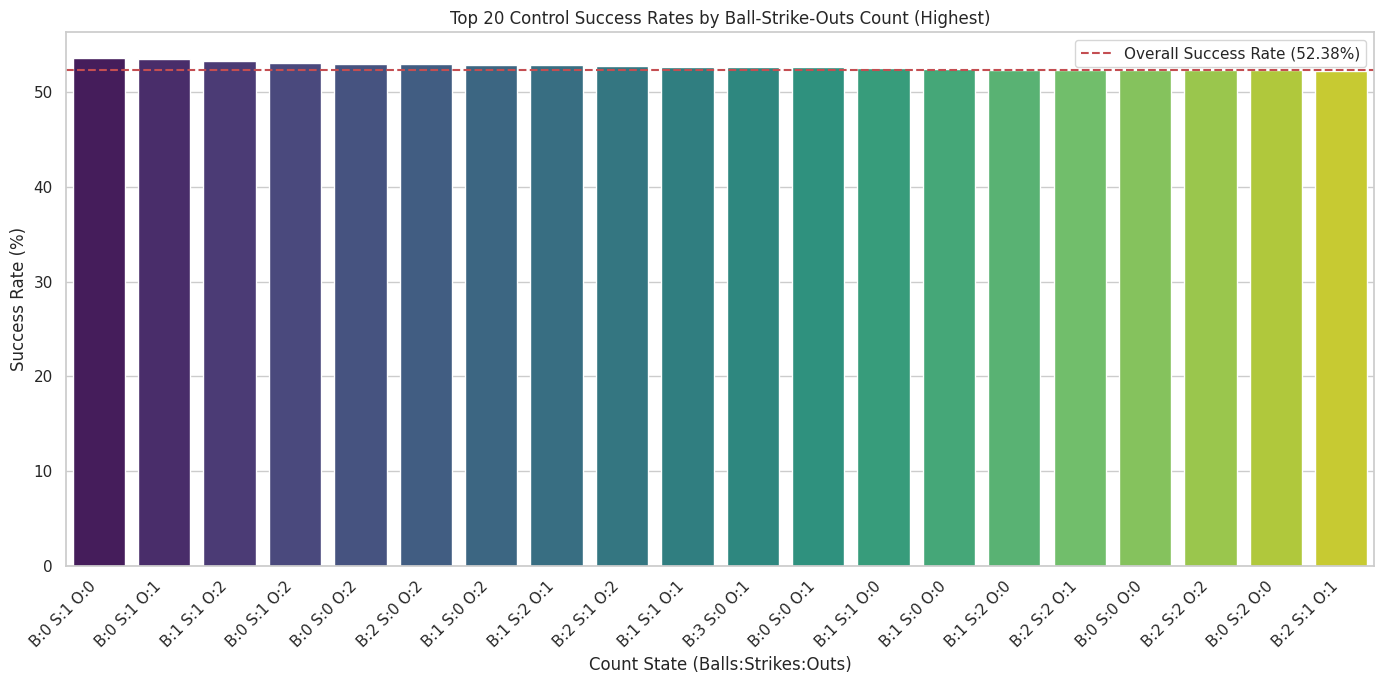

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Get the top 20 highest success rate combinations from the already processed count_outs DataFrame
top_20_success = count_outs.sort_values(
    "success_rate_pct",
    ascending=False
).head(20)

# Create a combined count state for plotting for better readability on the x-axis
top_20_success["count_state"] = (
    'B:' + top_20_success["balls_before"].astype(str) +
    ' S:' + top_20_success["strikes_before"].astype(str) +
    ' O:' + top_20_success["outs_before"].astype(str)
)

plt.figure(figsize=(14, 7))
# Use hue to ensure each bar has a distinct color, and set legend=False as hue is self-explanatory from x-axis
sns.barplot(x="count_state", y="success_rate_pct", data=top_20_success, palette="viridis", hue="count_state", legend=False)
plt.axhline(y=overall_rate * 100, color='r', linestyle='--', label=f'Overall Success Rate ({overall_rate*100:.2f}%)')
plt.title('Top 20 Control Success Rates by Ball-Strike-Outs Count (Highest)')
plt.xlabel('Count State (Balls:Strikes:Outs)')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

작은 표본은 과대해석하면 안되므로, 아래와 같이 표본이 충분한 것만 보는 것도 좋다.

In [38]:
count_outs[
    count_outs["count"] >= 5000
].sort_values("success_rate_pct")

,balls_before,strikes_before,outs_before,count,mean,success_rate_pct
30,3,1,0,11711,0.489796,48.979592
33,3,2,0,23441,0.491831,49.183055
27,3,0,0,5991,0.491905,49.190452
34,3,2,1,23027,0.498024,49.802406
29,3,0,2,6097,0.503034,50.303428
31,3,1,1,11651,0.504764,50.476354
35,3,2,2,24070,0.508683,50.868301
18,2,0,0,17958,0.511360,51.135984
21,2,1,0,27111,0.515621,51.562097
8,0,2,2,28342,0.515631,51.563051


# **16. 점수 변수 기본 통계**

In [39]:
SCORE_COLS = [
    "run_top_before",
    "run_bot_before",
    "run_total_before",
    "score_diff_home",
    "score_diff_pitcher_team",
]

df[SCORE_COLS].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.5,
        0.75,
        0.95,
        0.99,
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
run_top_before,1475092.0,2.557856,2.914232,0.0,0.0,0.0,0.0,2.0,4.0,8.0,12.0,30.0
run_bot_before,1475092.0,2.357027,2.766365,0.0,0.0,0.0,0.0,1.0,4.0,8.0,12.0,26.0
run_total_before,1475092.0,4.914883,4.500625,0.0,0.0,0.0,1.0,4.0,7.0,14.0,19.0,37.0
score_diff_home,1475092.0,-0.200829,3.469210,-27.0,-10.0,-6.0,-2.0,0.0,1.0,6.0,9.0,20.0
score_diff_pitcher_team,1475092.0,0.060107,3.474498,-27.0,-9.0,-6.0,-2.0,0.0,2.0,6.0,10.0,27.0


# **17. 점수 변수 Histogram**

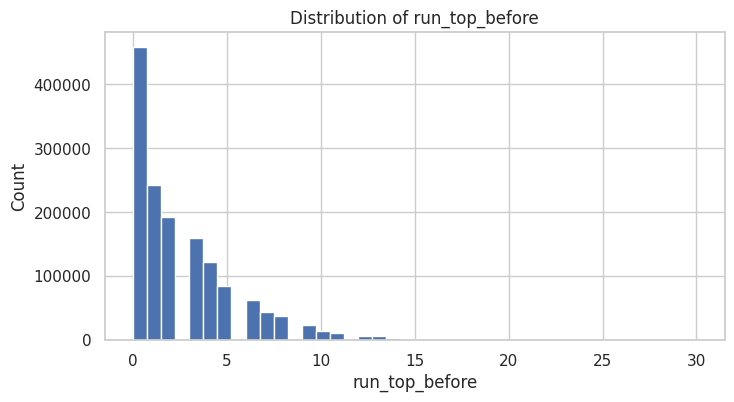

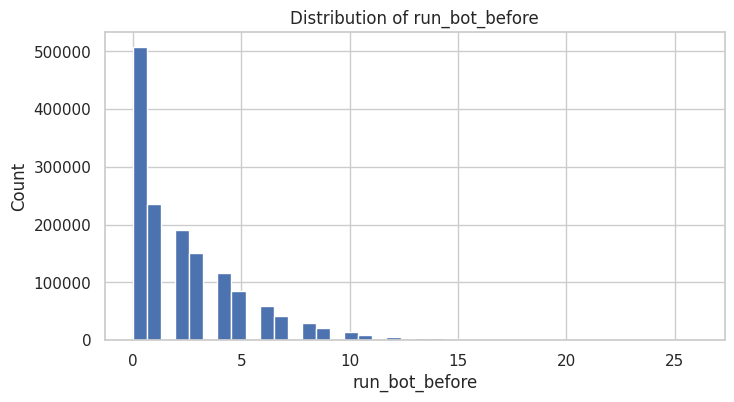

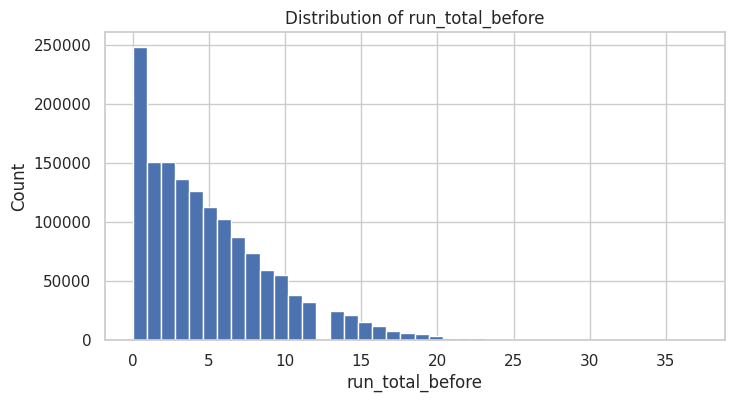

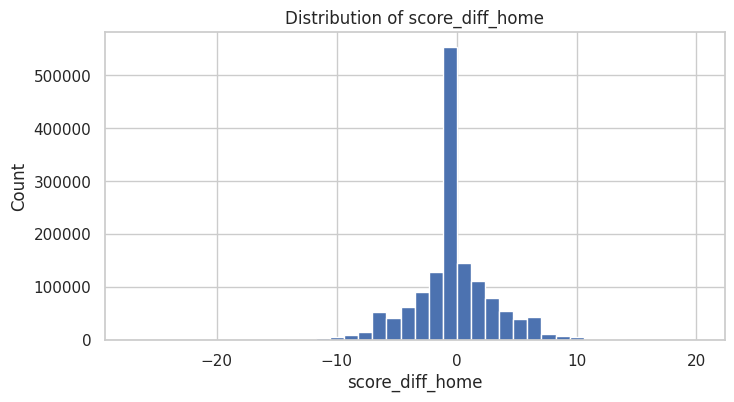

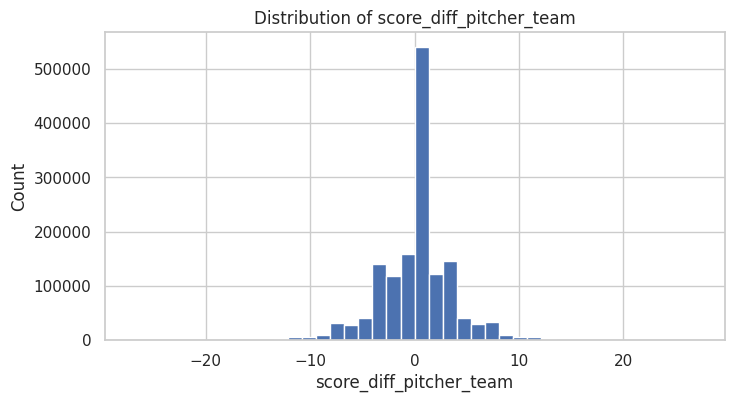

In [40]:
for col in SCORE_COLS:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[col],
        bins=40
    )

    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")

    plt.show()

# **18. score_diff_pitcher_team을 직접 분석**

In [41]:
score_diff_table = (
    df
    .groupby("score_diff_pitcher_team")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

score_diff_table["success_rate_pct"] = (
    score_diff_table["mean"] * 100
)

score_diff_table[
    score_diff_table["count"] >= 1000
]

,score_diff_pitcher_team,count,mean,success_rate_pct
13,-13,1299,0.487298,48.729792
14,-12,2093,0.509317,50.931677
15,-11,3186,0.522913,52.291274
16,-10,5250,0.499429,49.942857
17,-9,8500,0.501647,50.164706
18,-8,12381,0.506421,50.642113
19,-7,19398,0.501701,50.170121
20,-6,28226,0.509885,50.988450
21,-5,39660,0.510061,51.006051
22,-4,56499,0.516753,51.675251


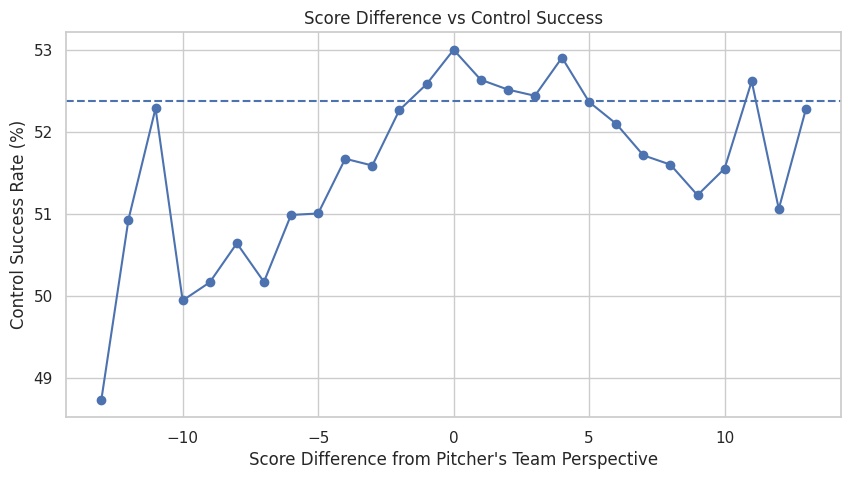

In [42]:
plot_df = score_diff_table[
    score_diff_table["count"] >= 1000
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["score_diff_pitcher_team"],
    plot_df["success_rate_pct"],
    marker="o"
)

plt.axhline(
    overall_rate * 100,
    linestyle="--"
)

plt.xlabel("Score Difference from Pitcher's Team Perspective")
plt.ylabel("Control Success Rate (%)")
plt.title("Score Difference vs Control Success")

plt.show()

# **19. 투수팀 입장에서 이기고/비기고/지는 상황**
해석하기 쉬운 파생 변수를 EDA 목적
(범주화)

In [43]:
df["score_state"] = np.select(
    [
        df["score_diff_pitcher_team"] < 0,
        df["score_diff_pitcher_team"] == 0,
        df["score_diff_pitcher_team"] > 0,
    ],
    [
        "trailing",
        "tied",
        "leading",
    ],
    default="unknown"
)

score_state_table = target_rate_table(
    df,
    "score_state"
)

score_state_table

,score_state,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,leading,560195,0.524555,52.455484,0.078887
1,tied,377192,0.530072,53.007222,0.630624
2,trailing,537705,0.518520,51.852038,-0.524560


# **20. 점수차 절댓값**

In [44]:
df["abs_score_diff"] = (
    df["score_diff_pitcher_team"].abs()
)

abs_diff_table = (
    df
    .groupby("abs_score_diff")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

abs_diff_table["success_rate_pct"] = (
    abs_diff_table["mean"] * 100
)

display(
    abs_diff_table[
        abs_diff_table["count"] >= 1000
    ]
)

,abs_score_diff,count,mean,success_rate_pct
0,0,377192,0.530072,53.007222
1,1,322455,0.526139,52.613853
2,2,239917,0.523981,52.398121
3,3,170173,0.520300,52.029993
4,4,115394,0.523060,52.306012
5,5,80453,0.516973,51.697264
6,6,57578,0.515561,51.556150
7,7,39428,0.509562,50.956173
8,8,25793,0.511418,51.141783
9,9,17686,0.507181,50.718082


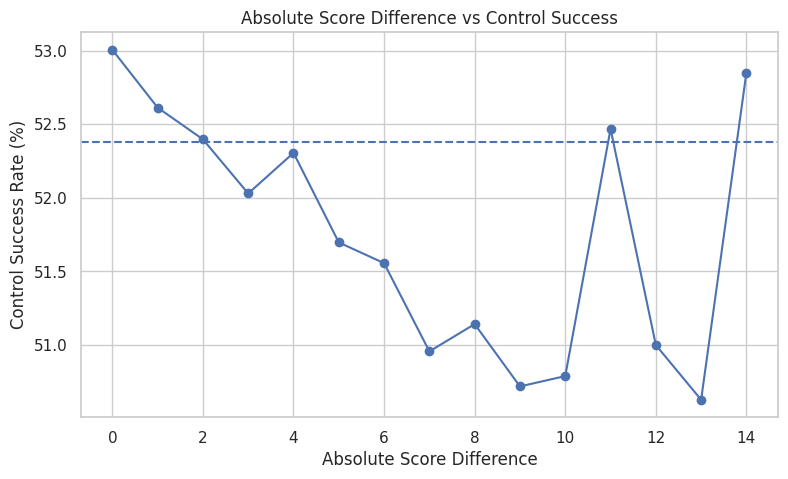

In [45]:
plot_df = abs_diff_table[
    abs_diff_table["count"] >= 1000
]

plt.figure(figsize=(9, 5))

plt.plot(
    plot_df["abs_score_diff"],
    plot_df["success_rate_pct"],
    marker="o"
)

plt.axhline(
    overall_rate * 100,
    linestyle="--"
)

plt.xlabel("Absolute Score Difference")
plt.ylabel("Control Success Rate (%)")
plt.title("Absolute Score Difference vs Control Success")

plt.show()

# **21. run_total_before 분석**

In [46]:
run_total_table = (
    df
    .groupby("run_total_before")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

run_total_table["success_rate_pct"] = (
    run_total_table["mean"] * 100
)

display(
    run_total_table[
        run_total_table["count"] >= 1000
    ]
)

,run_total_before,count,mean,success_rate_pct
0,0,248289,0.532670,53.266959
1,1,150682,0.527614,52.761445
2,2,150834,0.526002,52.600210
3,3,136607,0.525661,52.566120
4,4,125721,0.529076,52.907629
5,5,112277,0.524702,52.470230
6,6,102189,0.520653,52.065291
7,7,87301,0.514748,51.474783
8,8,73687,0.517120,51.711971
9,9,59462,0.517221,51.722108


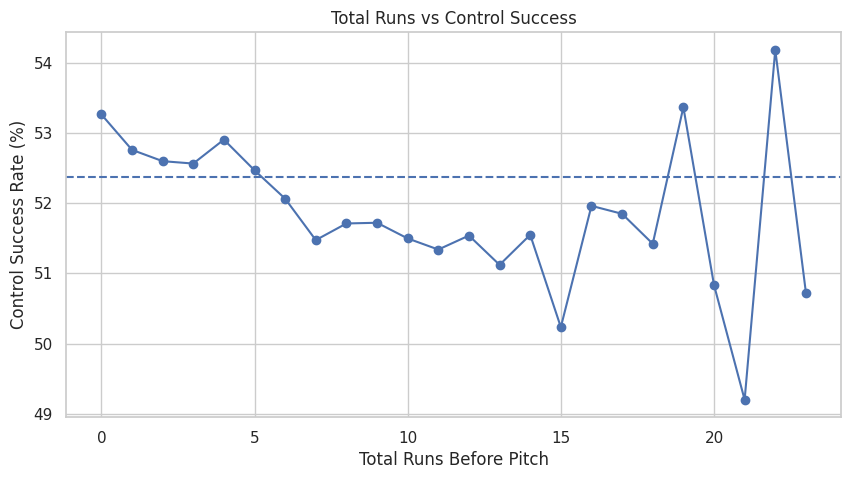

In [47]:
plot_df = run_total_table[
    run_total_table["count"] >= 1000
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["run_total_before"],
    plot_df["success_rate_pct"],
    marker="o"
)

plt.axhline(
    overall_rate * 100,
    linestyle="--"
)

plt.xlabel("Total Runs Before Pitch")
plt.ylabel("Control Success Rate (%)")
plt.title("Total Runs vs Control Success")

plt.show()

총점 때문에 제구가 변한다라고 바로 일반화하기 어렵다.

inning같은 변수와 얽혀 있을 수 있기 때문

# **22. inning과 교차 확인**

그래서 inning과 교차 확인.
이번에는 담당 범위 외 변수지만 confounding 확인 목적으로만 사용한다.

In [48]:
inning_run = (
    df
    .groupby(["inning", "run_total_before"])[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

inning_run["success_rate_pct"] = (
    inning_run["mean"] * 100
)

inning_run.head()

,inning,run_total_before,count,mean,success_rate_pct
0,1,0,121526,0.531779,53.177921
1,1,1,24035,0.533971,53.397129
2,1,2,13406,0.533343,53.334328
3,1,3,6908,0.522872,52.287203
4,1,4,3231,0.549675,54.967502


In [49]:
inning_total = (
    df
    .groupby("inning")["run_total_before"]
    .mean()
)

inning_total

,run_total_before
inning,
1,0.591110
2,1.698344
3,2.759508
4,3.895598
5,4.989935
6,6.105384
7,7.194112
8,8.352557
9,9.313662


이 결과가 크게 증가한다면:

run_total_before는 경기 진행 정도와 강한 관계가 있다.

는 걸 확인할 수 있음

# **23. 이번 대회에서 아주 중요한 Season Drift**

In [50]:
season_table = (
    df
    .groupby("season")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

season_table["success_rate_pct"] = (
    season_table["mean"] * 100
)

season_table

,season,count,mean,success_rate_pct
0,2019,237413,0.564670,56.467001
1,2020,244087,0.532712,53.271170
2,2021,247088,0.532762,53.276161
3,2022,247472,0.528920,52.892044
4,2023,245525,0.499957,49.995723
5,2024,253507,0.486105,48.610492


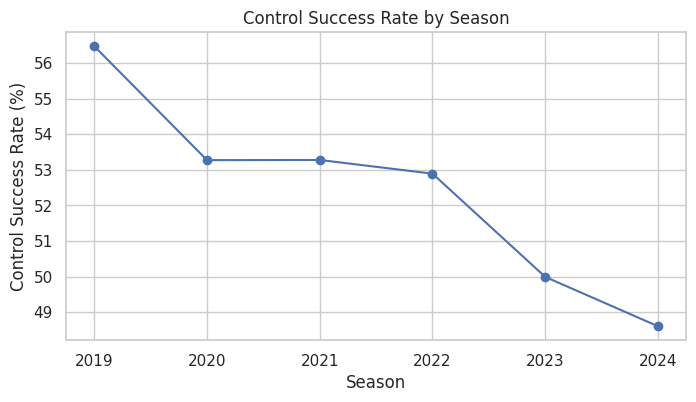

In [51]:
plt.figure(figsize=(8, 4))

plt.plot(
    season_table["season"],
    season_table["success_rate_pct"],
    marker="o"
)

plt.xlabel("Season")
plt.ylabel("Control Success Rate (%)")
plt.title("Control Success Rate by Season")

plt.show()

# **24. Count 효과가 시즌마다 유지되는지 확인**

In [52]:
season_count = (
    df
    .groupby(
        [
            "season",
            "balls_before",
            "strikes_before"
        ]
    )[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

season_count["success_rate_pct"] = (
    season_count["mean"] * 100
)

season_count["count_state"] = (
    season_count["balls_before"].astype(str)
    + "-"
    + season_count["strikes_before"].astype(str)
)

season_count.head()

,season,balls_before,strikes_before,count,mean,success_rate_pct,count_state
0,2019,0,0,62587,0.571333,57.133270,0-0
1,2019,0,1,29921,0.566358,56.635808,0-1
2,2019,0,2,14380,0.534840,53.484006,0-2
3,2019,1,0,24834,0.579810,57.980994,1-0
4,2019,1,1,24217,0.572573,57.257299,1-1


In [53]:
season_count[
    season_count["count_state"] == "3-2"
][
    [
        "season",
        "count",
        "success_rate_pct"
    ]
]

,season,count,success_rate_pct
11,2019,11095,55.673727
23,2020,11767,50.548143
35,2021,12203,51.421782
47,2022,11806,50.169405
59,2023,11896,46.561870
71,2024,11771,45.697052


In [54]:
season_count[
    season_count["count_state"].isin(
        ["0-0", "0-2", "3-0", "3-1", "3-2"]
    )
].pivot(
    index="season",
    columns="count_state",
    values="success_rate_pct"
)

count_state,0-0,0-2,3-0,3-1,3-2
season,,,,,
2019,57.133270,53.484006,54.456929,56.173404,55.673727
2020,53.270210,53.204412,50.504393,51.074908,50.548143
2021,53.637950,53.164114,52.124563,50.928180,51.421782
2022,53.159915,52.183392,50.622998,50.954505,50.169405
2023,50.285090,50.178989,48.775367,48.028242,46.561870
2024,48.628994,49.229341,48.195395,45.913621,45.697052


# **25. 시즌 평균 대비 Count 효과 보기**



---

이건 한단계 높은 EDA 분석.

시즌 자체의 성공률이 변하고 있기 때문에
각 count의 절대 성공률 뿐 아니라

그 시즌 평균보다 얼마나 높은가/낮은가를 봐야 한다.



In [56]:
season_avg = (
    df
    .groupby("season")[TARGET]
    .mean()
    .rename("season_avg")
    .reset_index()
)

season_count_adj = season_count.merge(
    season_avg,
    on="season",
    how="left"
)

season_count_adj["diff_vs_season_pp"] = (
    season_count_adj["mean"]
    -
    season_count_adj["season_avg"]
) * 100

season_count_adj[
    season_count_adj["count_state"] == "3-2"
][
    [
        "season",
        "success_rate_pct",
        "diff_vs_season_pp"
    ]
]

,season,success_rate_pct,diff_vs_season_pp
11,2019,55.673727,-0.793274
23,2020,50.548143,-2.723027
35,2021,51.421782,-1.854379
47,2022,50.169405,-2.722639
59,2023,46.561870,-3.433854
71,2024,45.697052,-2.913440


이걸 보면 3-2가 단순히 최근 시즌이라 낮은 건지, 아니면 같은 시즌 안에서도 실제로 낮은 상황인지 구분할 수 있다.

# **26. 상관계수도 보되 참고용으로만**

In [57]:
corr_cols = GROUP2_COLS + [TARGET]

pearson_corr = (
    df[corr_cols]
    .corr(method="pearson")[TARGET]
    .sort_values()
)

print("Pearson correlation")
print(pearson_corr)

Pearson correlation
balls_before              -0.012057
run_total_before          -0.011327
run_bot_before            -0.009761
run_top_before            -0.008228
strikes_before            -0.005077
score_diff_home           -0.000872
outs_before                0.003877
score_diff_pitcher_team    0.005775
control_success            1.000000
Name: control_success, dtype: float64


In [58]:
spearman_corr = (
    df[corr_cols]
    .corr(method="spearman")[TARGET]
    .sort_values()
)

print("Spearman correlation")
print(spearman_corr)

Spearman correlation
run_total_before          -0.012094
balls_before              -0.010439
run_bot_before            -0.009278
run_top_before            -0.008815
strikes_before            -0.004762
score_diff_home            0.000141
outs_before                0.003878
score_diff_pitcher_team    0.006015
control_success            1.000000
Name: control_success, dtype: float64


correlation이 낮기는 하지만, Tree 모델에서는 비선형 관계와 interaction이 존재할 수 있다.

# **27. 담당 변수끼리 상관관계**

In [59]:
feature_corr = df[GROUP2_COLS].corr()

feature_corr

,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,score_diff_home,score_diff_pitcher_team
balls_before,1.000000,0.375560,0.014453,0.001314,0.005008,0.003929,0.002890,-0.006871
strikes_before,0.375560,1.000000,0.001293,-0.006025,-0.007666,-0.008613,-0.001051,0.012141
outs_before,0.014453,0.001293,1.000000,0.030259,0.029661,0.037824,-0.001767,-0.053324
run_top_before,0.001314,-0.006025,0.030259,1.000000,0.254912,0.804202,-0.636760,0.033411
run_bot_before,0.005008,-0.007666,0.029661,0.254912,1.000000,0.779722,0.583272,0.025984
run_total_before,0.003929,-0.008613,0.037824,0.804202,0.779722,1.000000,-0.053797,0.037606
score_diff_home,0.002890,-0.001051,-0.001767,-0.636760,0.583272,-0.053797,1.000000,-0.007346
score_diff_pitcher_team,-0.006871,0.012141,-0.053324,0.033411,0.025984,0.037606,-0.007346,1.000000


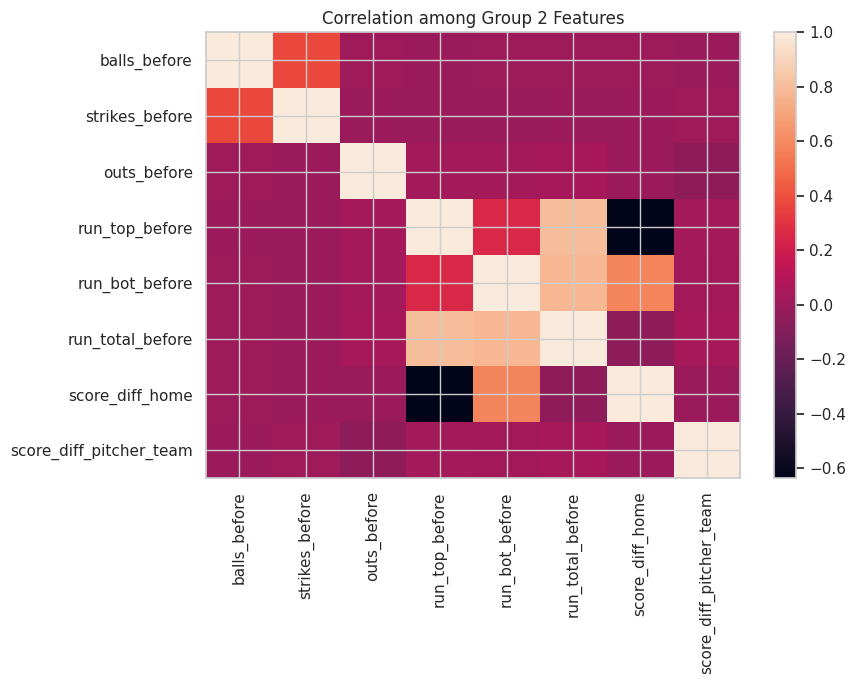

In [60]:
plt.figure(figsize=(9, 7))

img = plt.imshow(
    feature_corr.values,
    aspect="auto"
)

plt.colorbar(img)

plt.xticks(
    range(len(feature_corr.columns)),
    feature_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(feature_corr.index)),
    feature_corr.index
)

plt.title("Correlation among Group 2 Features")

plt.tight_layout()
plt.show()

# **28. 회의용 주요 결과**

In [61]:
print("=" * 70)
print("GROUP 2 EDA SUMMARY")
print("=" * 70)

print(
    f"\n전체 행 수: {len(df):,}"
)

print(
    f"전체 control_success: "
    f"{overall_rate*100:.2f}%"
)

print("\n[Count별 성공률]")

display(
    count_table[
        [
            "count_state",
            "count",
            "success_rate_pct",
            "diff_vs_overall_pp"
        ]
    ].sort_values("success_rate_pct")
)

print("\n[Out별 성공률]")

display(
    outs_table
)

print("\n[투수팀 점수 상태]")

display(
    score_state_table
)

print("\n[시즌별 성공률]")

display(
    season_table
)

print("\n[중복 관계 검증]")

print(
    "run_total = run_top + run_bot:",
    check_total.mean()
)

print(
    "score_diff_home = run_bot - run_top:",
    check_home_diff.mean()
)

print(
    "score_diff_pitcher_team 재구성:",
    check_pitcher_diff.mean()
)

GROUP 2 EDA SUMMARY

전체 행 수: 1,475,092
전체 control_success: 52.38%

[Count별 성공률]


,count_state,count,success_rate_pct,diff_vs_overall_pp
11,3-2,70538,49.960305,-2.416292
10,3-1,35425,50.438956,-1.937642
9,3-0,18060,50.730897,-1.645701
2,0-2,89281,51.853138,-0.523460
6,2-0,54187,51.888829,-0.487768
8,2-2,119702,52.098545,-0.278053
7,2-1,80348,52.175536,-0.201061
5,1-2,139598,52.444161,0.067564
3,1-0,154878,52.485182,0.108584
0,0-0,380996,52.656721,0.280123



[Out별 성공률]


,outs_before,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,0,505924,0.521398,52.139847,-0.236750
1,1,490634,0.523894,52.389357,0.012760
2,2,478534,0.526138,52.613816,0.237219



[투수팀 점수 상태]


,score_state,count,success_rate,success_rate_pct,diff_vs_overall_pp
0,leading,560195,0.524555,52.455484,0.078887
1,tied,377192,0.530072,53.007222,0.630624
2,trailing,537705,0.518520,51.852038,-0.524560



[시즌별 성공률]


,season,count,mean,success_rate_pct
0,2019,237413,0.564670,56.467001
1,2020,244087,0.532712,53.271170
2,2021,247088,0.532762,53.276161
3,2022,247472,0.528920,52.892044
4,2023,245525,0.499957,49.995723
5,2024,253507,0.486105,48.610492



[중복 관계 검증]
run_total = run_top + run_bot: 1.0
score_diff_home = run_bot - run_top: 1.0
score_diff_pitcher_team 재구성: 1.0


EDA에서의 유의미한 질문

1. balls_before, strikes_before, outs_before는 정상 범위인가?
2. 어느 count에서 제구 성공률이 가장 높고 낮은가?
3. 3-ball 상황이 실제로 다른가?
4. Full count인 3-2가 특별한가?
5. 아웃 카운트는 실질적인 차이가 있는가?
6. 투수팀이 앞설 때/동점일 때/질 때 차이가 있는가?
7. 점수차가 커질수록 관계가 선형인가, 비선형인가?
8. run_total, score_diff_home 등이 사실 다른 변수에서 완전히 계산 가능한가?
9. 2019~2024 동안 같은 패턴이 유지되는가?
10. 그래서 다음 모델링 단계에서 어떤 feature를 검증 후보로 올릴 것인가?